In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120 

import os
os.makedirs("../figures", exist_ok=True)

np.random.seed(43)

print('a')

a


In [ ]:
# Paramètres
n     = 50         # nombre d'observations
p     = 32         # points sur la grille
N     = 3          # nombre de fréquences
d     = 2*N + 1    # dimension du vecteur u
sigma = 0.3        # écart-type du bruit
n_z   = 100        # points de quadrature pour approcher l'intégrale en z

xgrid = np.linspace(0, 2*np.pi, p, endpoint=False)  # grille spatiale (p,)
zgrid = np.linspace(0, 2*np.pi, n_z, endpoint=False)  # grille de quadrature (n_z,)
dz    = 2*np.pi / n_z   # pas de quadrature

# Vrai paramètre (inconnu en pratique)
u_true = np.random.randn(d)

# Décalages Z_i tirés uniformément
Z = np.random.uniform(0, 2*np.pi, n)


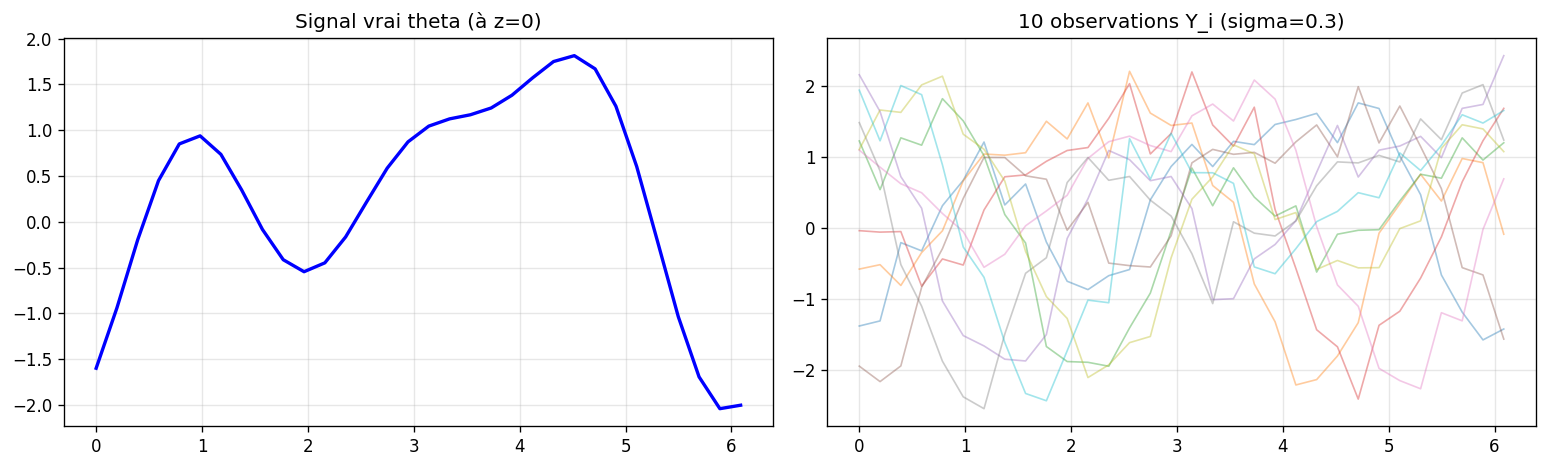

In [3]:
def build_phi(z):
    """
    Matrice Phi(z) de taille (p, d).
    Phi(z) @ u donne le signal theta_u sur la grille, translaté de z.
    """
    phi = np.zeros((p, d))
    phi[:, 0] = 1.0
    for k in range(1, N + 1):
        phi[:, 2*k - 1] = np.cos(k * (xgrid - z))  # coeff a_k
        phi[:, 2*k]     = np.sin(k * (xgrid - z))  # coeff b_k
    return phi  # (p, d)


def build_phiu(z, u):
    """Signal theta_u évalué sur la grille pour le décalage z. Retourne (p,)."""
    return build_phi(z) @ u


# Construction des observations : Y_i = Phi(Z_i) u + sigma * bruit
signals      = np.array([build_phiu(z=zi, u=u_true) for zi in Z])  # (n, p)
observations = signals + sigma * np.random.randn(n, p)              # (n, p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(xgrid, build_phiu(z=0, u=u_true), 'b-', lw=2)
ax1.set_title('Signal vrai theta (à z=0)'); ax1.grid(alpha=0.3)
for i in range(min(n, 10)):
    ax2.plot(xgrid, observations[i], alpha=0.4, lw=1)
ax2.set_title(f'{min(n,10)} observations Y_i (sigma={sigma})')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/signaux_1D.pdf", bbox_inches = "tight")
plt.show()
plt.close()  



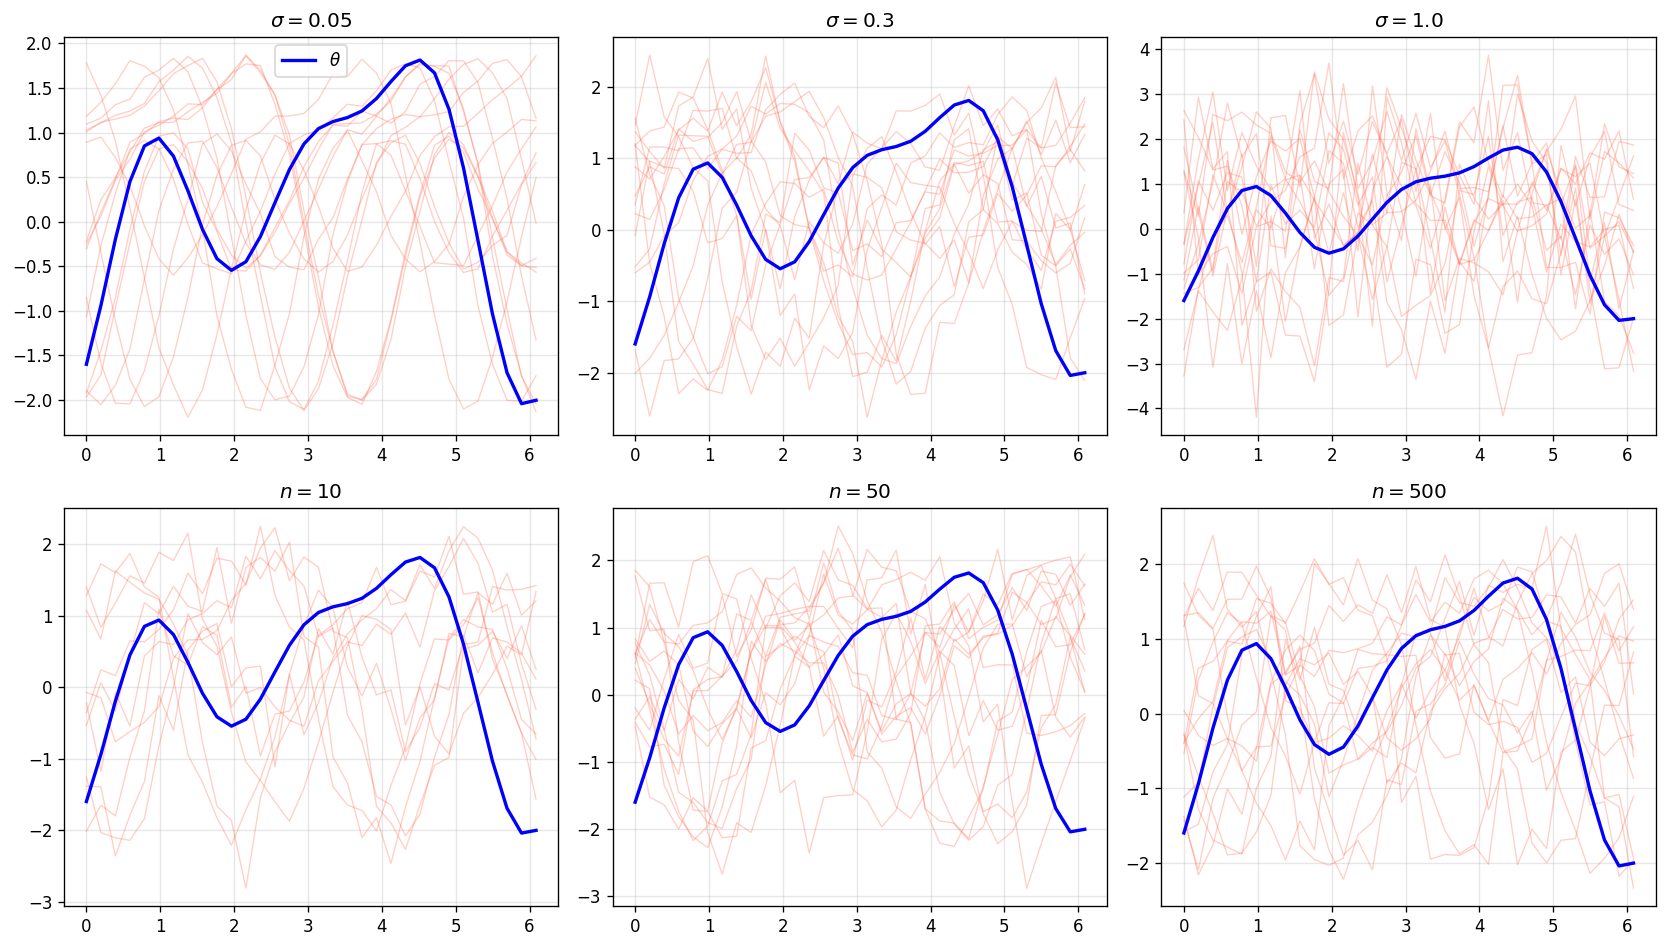

In [ ]:
# Figure  : influence des paramètres 
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

configs = [
    dict(sigma=0.05, n=50, title=r"$\sigma=0.05$"),
    dict(sigma=0.3,  n=50, title=r"$\sigma=0.3$"),
    dict(sigma=1.0,  n=50, title=r"$\sigma=1.0$"),
    dict(sigma=0.3,  n=10,  title=r"$n=10$"),
    dict(sigma=0.3,  n=50,  title=r"$n=50$"),
    dict(sigma=0.3,  n=500, title=r"$n=500$"),
]

for ax, cfg in zip(axes.flat, configs):
    Z_tmp = np.random.uniform(0, 2*np.pi, cfg["n"])
    Y_tmp = np.array([build_phi(z) @ u_true for z in Z_tmp])
    Y_tmp += cfg["sigma"] * np.random.randn(*Y_tmp.shape)
    for i in range(min(cfg["n"], 15)):
        ax.plot(xgrid, Y_tmp[i], color="tomato", alpha=0.3, lw=0.8)
    ax.plot(xgrid, build_phi(0) @ u_true, "b-", lw=2, label=r"$\theta$")
    ax.set_title(cfg["title"]); ax.grid(alpha=0.3)

axes[0,0].legend(); plt.tight_layout()
plt.savefig("../figures/simulation_parametres.pdf", bbox_inches="tight")
plt.show()
plt.close()  

In [ ]:
QI_MAX = 745.0


def qi(z, y, u):
    residual = y - build_phiu(z=z, u=u)              # (p,)  ← correct, pas de np.sum()
    sq_norm  = float(np.dot(residual, residual))     # ||résidu||²
    return min(sq_norm / (2.0 * sigma**2), QI_MAX)  # clipping anti-overflow


def log_likelihood(u):
    """
    Log-vraisemblance observée
    """

    C  = -0.5 * n * p * np.log(2*np.pi*sigma**2) - n * np.log(2*np.pi)
    ll = C

    for yi in observations:

        log_w = np.array([-qi(z=z, y=yi, u=u) for z in zgrid])  # (n_z,)

        ll += np.log(dz) + logsumexp(log_w)

    return ll


def compute_gradient(u):
    """
    Gradient de la log-vraisemblance
    """
    grad_total = np.zeros(d)

    for yi in observations:
        log_w = np.array([-qi(z=z, y=yi, u=u) for z in zgrid])  # (n_z,)


        m = log_w.max()  
        w = np.exp(log_w - m)  
        w_sum = w.sum()

        if w_sum < 1e-300:
            continue

        weights = w / w_sum  # normalisation

        num = np.zeros(d)
        for q, z in enumerate(zgrid):
            residu = yi - build_phiu(z=z, u=u)          # (p,)
            num   += weights[q] * (build_phi(z).T @ residu)  # (d,)

        grad_total += num

    return grad_total / sigma**2


In [ ]:
def gradient_ascent_armijo(u0, eta0=1.0, n_iter=150, c_armijo=1e-4,
                           tol=1e-5, verbose=False):
    """
    Montée de gradient avec recherche de pas par backtracking Armijo.
    """
    u_cur = u0.copy()
    hist_ll   = [log_likelihood(u_cur)]
    hist_grad = []
    eta = eta0

    for k in range(n_iter):
        # Calcul du gradient
        g      = compute_gradient(u_cur)
        g_norm = np.linalg.norm(g)
        hist_grad.append(g_norm)

        # Critère d'arrêt : gradient quasi-nul
        if g_norm < tol:
            if verbose:
                print(f'  Convergence (||g||={g_norm:.2e}) à iter {k}')
            break

        #  Backtracking Armijo 
        ll_cur = hist_ll[-1]
        step   = eta
        for _ in range(60):          # au plus 60 divisions par 2
            u_try  = u_cur + step * g
            ll_try = log_likelihood(u_try)
            # Condition d'Armijo
            if np.isfinite(ll_try) and ll_try >= ll_cur + c_armijo * step * g_norm**2:
                break
            step *= 0.5
        else:
            if verbose:
                print(f'  Pas trop petit à iter {k}, arrêt.')
            break

        u_cur = u_try
        hist_ll.append(ll_try)

        # on essaie d'agrandir légèrement le pas à la prochaine iter
        eta = min(2.0 * step, eta0)

        if verbose and (k + 1) % 25 == 0:
            print(f'  iter {k+1:3d} : ll={ll_try:.2f}  ||g||={g_norm:.3e}  step={step:.2e}')

    return u_cur, np.array(hist_ll), np.array(hist_grad)


In [7]:
n_starts = 6
results  = []

def translation_error(u_hat, u_true, xgrid):
    p = len(xgrid)
    sig_hat  = build_phiu(0, u_hat)   # (p,) — signal sur la grille
    sig_true = build_phiu(0, u_true)  # (p,)
    corr = np.fft.irfft(
        np.fft.rfft(sig_hat).conj() * np.fft.rfft(sig_true), n=p
    )
    best_shift = np.argmax(corr)
    sig_aligned = np.roll(sig_hat, best_shift)
    return np.linalg.norm(sig_aligned - sig_true) / np.linalg.norm(sig_true)

for s in range(n_starts):
    np.random.seed(100 + s)
    u0 = np.random.randn(d)

    u_hat, hist_ll, hist_grad = gradient_ascent_armijo(
        u0, eta0=1.0, n_iter=150, verbose=False
    )

    err_rel = translation_error(u_hat, u_true, xgrid=xgrid)
    results.append({
        'u_hat':     u_hat,
        'hist_ll':   hist_ll,
        'hist_grad': hist_grad,
        'll_final':  hist_ll[-1],
        'err_rel':   err_rel,
    })
    print(f'start {s} : ll_final={hist_ll[-1]:8.2f}   err_rel={err_rel:.4f}')

best   = max(results, key=lambda r: r['ll_final'])
u_best = best['u_hat']
print(f'\nMeilleur start : ll={best["ll_final"]:.3f}   err_rel={best["err_rel"]:.4f}')


start 0 : ll_final= -510.37   err_rel=0.0762
start 1 : ll_final= -510.37   err_rel=0.1192
start 2 : ll_final= -510.37   err_rel=0.0904
start 3 : ll_final= -510.37   err_rel=0.1047
start 4 : ll_final= -510.37   err_rel=0.1336
start 5 : ll_final= -510.37   err_rel=0.1771

Meilleur start : ll=-510.366   err_rel=0.0904


## 6. Visualisation

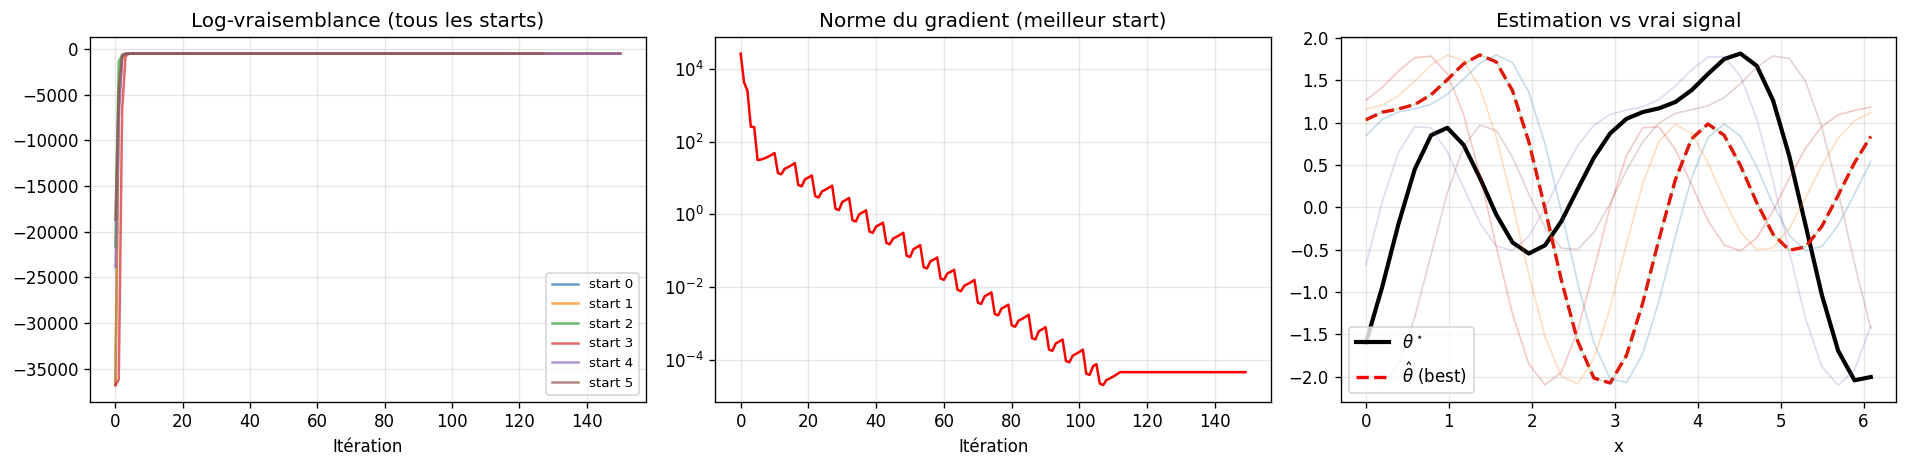

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Log-vraisemblance
for s, r in enumerate(results):
    axes[0].plot(r['hist_ll'], alpha=0.7, label=f'start {s}')
axes[0].set_xlabel('Itération')
axes[0].set_title('Log-vraisemblance (tous les starts)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Norme du gradient
axes[1].semilogy(best['hist_grad'], 'r-')
axes[1].set_xlabel('Itération')
axes[1].set_title('Norme du gradient (meilleur start)')
axes[1].grid(alpha=0.3, which='both')

# Signal estimé vs vrai
theta_true_grid = build_phiu(z=0, u=u_true)
theta_hat_grid  = build_phiu(z=0, u=u_best)
axes[2].plot(xgrid, theta_true_grid, 'k-',  lw=2.5, label=r'$\theta^\star$')
axes[2].plot(xgrid, theta_hat_grid,  'r--', lw=2,   label=r'$\hat{\theta}$ (best)')
for r in results:
    axes[2].plot(xgrid, build_phiu(z=0, u=r['u_hat']), alpha=0.25, lw=1)
axes[2].set_xlabel('x'); axes[2].set_title('Estimation vs vrai signal')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()
